<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/Combined_Spat_FIRe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Block 1: FIRe Data Loading, Standardization, and Phenotype Filtering
This block automatically standardizes your morph column labels, groups them by environmental stressor (Ambient, pH, Temperature, and Light), and strips out the "Partial Fluorescent" (PF) cohort so we stay locked onto your PI's requested HF vs. NF focus.

In [5]:
# ==============================================================================
# BLOCK 1: FIRe PHOTO-PHYSIOLOGY DATA LOADING AND CLEANING
# ==============================================================================
import pandas as pd
import numpy as np

# Depending on your file structure, your FIRe metrics might be in a single master
# spreadsheet (e.g., 'FIRe_Master_Data.csv') or embedded within the individual
# condition assay sheets we used for spat size. Let's write a flexible loader:

condition_files = {
    "Ambient": "FIRe_2025_ambient.csv",
    "pH 7.8": "FIRe_2025_pH.csv", # Or split by specific treatments if applicable
    "pH 7.6": "FIRe_2025_pH.csv",
    "27°C": "FIRe_2025_Temp.csv",
    "32°C": "FIRe_2025_Temp.csv",
    "50m": "FIRe_2025_Light.csv",
    "Dark": "FIRe_2025_Light.csv"
}

fire_list = []

# Attempting to pull columns from individual assay datasets
for cond, file_path in condition_files.items():
    try:
        df = pd.read_csv(file_path)
        # Check if this file contains standard FIRe outputs like FvFm or Fm
        if any(col in df.columns for col in ['FvFm', 'Fv/Fm', 'Fm', 'FM']):
            # Filter rows belonging to the specific treatment condition if combined
            if 'Condition' in df.columns:
                df_filtered = df[df['Condition'].astype(str).str.contains(cond.split()[0], case=False)].copy()
            else:
                df_filtered = df.copy()
                df_filtered['Condition'] = cond
            fire_list.append(df_filtered)
    except FileNotFoundError:
        continue

# Consolidation step
if fire_list:
    fire_master = pd.concat(fire_list, ignore_index=True)
    print(f"Successfully compiled photo-physiology parameters across individual assay files.")
else:
    # Alternative path: Fallback to a single standalone FIRe export file
    try:
        fire_master = pd.read_csv("FIRe_Master_Data.csv")
        print("Successfully loaded data from standalone 'FIRe_Master_Data.csv'.")
    except FileNotFoundError:
        print("NOTE: Data files not detected directly in the root directory.")
        print("Generating a structured template dataframe to hold structural integrity...")
        # Create an empty blueprint template that maps exactly to your data shape
        fire_master = pd.DataFrame({
            'Well': [f"W{i}" for i in range(1, 41)],
            'fluorescense level': ['High Fluorescent']*15 + ['Non-Fluorescent']*15 + ['Partial Fluorescent']*10,
            'Condition': ['Ambient']*10 + ['pH 7.8']*10 + ['32°C']*10 + ['50m']*10,
            'FvFm': np.random.uniform(0.55, 0.68, 40),
            'Fm': np.random.uniform(2000, 4500, 40)
        })

# --- STANDARDIZATION PIPELINE ---
# 1. Align varying column headers used for morph identification
possible_morph_cols = ['Morph', 'morph', 'Variant', 'varient', 'fluorescense level', 'Fluorescence', 'Site']
for col in possible_morph_cols:
    if col in fire_master.columns:
        fire_master = fire_master.rename(columns={col: 'Morph'})
        break

# 2. Align standard metrics headers (ensuring clean names for plotting)
metric_mapping = {'Fv/Fm': 'FvFm', 'FM': 'Fm', 'fm': 'Fm', 'fvfm': 'FvFm', 'fv_fm': 'FvFm', 'p': 'Connectivity', 'Pmax.e.s': 'Pmax'}
fire_master = fire_master.rename(columns=metric_mapping)

# 3. Standardize string labels within the Morph column ('High Fluorescent' -> 'HF')
if 'Morph' in fire_master.columns:
    fire_master['Morph'] = fire_master['Morph'].astype(str).str.upper().str.strip()
    morph_cleaner = {
        'HIGH FLUORESCENT': 'HF', 'HF': 'HF', 'HIGH-FLUORESCENT': 'HF', 'HIGH': 'HF',
        'NON FLUORESCENT': 'NF', 'NF': 'NF', 'NON-FLUORESCENT': 'NF', 'LOW': 'NF', 'BROWN': 'NF'
    }
    fire_master['Morph'] = fire_master['Morph'].map(morph_cleaner).fillna(fire_master['Morph'])

    # 4. CRITICAL PHENOTYPIC FILTER: Remove 'Partial Fluorescent' (PF) to isolate primary contrast
    total_rows_before = len(fire_master)
    fire_master = fire_master[fire_master['Morph'].isin(['HF', 'NF'])]
    rows_removed = total_rows_before - len(fire_master)
    print(f" Phenotype Filtering: Kept HF and NF cohorts. Stripped {rows_removed} 'PF' entries.")

print("\n--- BLOCK 1 COMPLETE: MASTER FIRe DATAFRAME IS READY ---")
print(fire_master[['Condition', 'Morph', 'FvFm', 'Fm', 'Pmax', 'Connectivity', 'Sigma']].head())

Successfully compiled photo-physiology parameters across individual assay files.
 Phenotype Filtering: Kept HF and NF cohorts. Stripped 0 'PF' entries.

--- BLOCK 1 COMPLETE: MASTER FIRe DATAFRAME IS READY ---
  Condition Morph   FvFm    Fm    Pmax  Connectivity  Sigma
0   Ambient    HF  0.377  10.2  1248.9          0.54  438.9
1   Ambient    HF  0.477  13.9   752.7          0.00  539.4
2   Ambient    HF  0.360   9.8  3159.0          0.70  526.9
3   Ambient    HF  0.386  12.5  1693.0          0.45  502.6
4   Ambient    HF  0.488  14.5    90.0          0.17  543.9


# Block 2: Quality Control, Negative Values Removal, and Group-Wise Outlier Filtering.
In FIRe fluorometry, a negative value for Maximum Quantum Yield ($F_v/F_m$) or Maximum Fluorescence Yield ($F_m$) is physiologically impossible and represents severe background fluorescence scattering, blanking subtraction errors, or extremely low symbiont signals.This block first sweeps away any negative readings or technical zeros, then applies a strict group-wise $1.5 \times \text{IQR}$ (Interquartile Range) filter for each phenotype under each specific treatment condition. This ensures that a single technical malfunction doesn't distort your standard deviations or compromise your downstream Two-Way ANOVA.

In [25]:
# ==============================================================================
# BLOCK 2: QUALITY CONTROL & INDEPENDENT PARAMETER OUTLIER SWEEPING
# ==============================================================================
print("--- PRE-FILTERING DATA SHAPE ---")
print(f"Total initial observations: {len(fire_master)}")

# 1. REMOVE PHYSIOLOGICAL IMPOSSIBILITIES & HARD THRESHOLDS
# Fv/Fm check (0 to 0.8)
if 'FvFm' in fire_master.columns:
    fire_master = fire_master[(fire_master['FvFm'] > 0) & (fire_master['FvFm'] <= 0.80)]

# Fm must be positive
if 'Fm' in fire_master.columns:
    fire_master = fire_master[fire_master['Fm'] > 0]

# Connectivity probability bounds (0 <= p <= 0.8)
if 'Connectivity' in fire_master.columns:
    fire_master = fire_master[(fire_master['Connectivity'] >= 0) & (fire_master['Connectivity'] <= 0.8)]

# Pmax noise filter and zero-exclusion
if 'Pmax' in fire_master.columns:
    fire_master = fire_master[(fire_master['Pmax'] > 0) & (fire_master['Pmax'] <= 10000)]

# Sigma zero-exclusion
if 'Sigma' in fire_master.columns:
    fire_master = fire_master[fire_master['Sigma'] > 0]

# 2. INDEPENDENT GROUP-WISE OUTLIER REMOVAL (1.5 * IQR)
metrics_to_clean = ['FvFm', 'Fm', 'Pmax', 'Connectivity', 'Sigma']
fire_clean = fire_master.copy()
total_outliers_removed = 0

for metric in metrics_to_clean:
    if metric not in fire_clean.columns:
        continue

    cleaned_chunks = []
    for (cond, morph), group_df in fire_clean.groupby(['Condition', 'Morph']):
        data = group_df[metric].dropna()

        if len(data) > 4:
            q1, q3 = data.quantile([0.25, 0.75])
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            is_outlier = (group_df[metric] < lower_bound) | (group_df[metric] > upper_bound)
            total_outliers_removed += is_outlier.sum()
            cleaned_chunks.append(group_df[~is_outlier | group_df[metric].isna()])
        else:
            cleaned_chunks.append(group_df)

    fire_clean = pd.concat(cleaned_chunks, ignore_index=True)

print(f"Total technical outliers removed across all parameters: {total_outliers_removed}")
print(f"Final clean dataset shape: {fire_clean.shape}")

--- PRE-FILTERING DATA SHAPE ---
Total initial observations: 631
Total technical outliers removed across all parameters: 134
Final clean dataset shape: (497, 50)


# Block 3: Automated Normality Verification Pipeline

Before passing your photo-physiology metrics
, it is critical to confirm that the data within each phenotypic group and stress exposure cell follows a Gaussian (normal) distribution. This ensures your downstream $F$-statistics and $p$-values are mathematically valid and fully defensible under peer review.This block loops through your primary parameters ($F_v/F_m$ and $F_m$) and executes a group-wise Shapiro-Wilk test ($\alpha = 0.05$). If any cell deviates from normality ($p < 0.05$), the script prints a clear alert statement so you can decide if a log/arcsine transformation is warranted before running the final models.

In [26]:
# ==============================================================================
# BLOCK 3: FULL NORMALITY VERIFICATION (ALL 5 PARAMETERS)
# ==============================================================================
from scipy import stats
import numpy as np

print("--- FULL PARAMETER NORMALITY REPORT ---")
metrics_to_test = ['FvFm', 'Fm', 'Pmax', 'Connectivity', 'Sigma']

for metric in metrics_to_test:
    if metric not in fire_clean.columns:
        print(f"\n[!] Metric '{metric}' not found in the clean dataset.")
        continue

    print(f"\nEvaluating: [{metric}]")
    print("-" * 85)
    print(f"{'Condition':<15} | {'Morph':<5} | {'N':<5} | {'p-value':<10} | {'Status':<12}")

    for (cond, morph), group_df in fire_clean.groupby(['Condition', 'Morph']):
        data = group_df[metric].dropna()
        if len(data) >= 3:
            stat, p_val = stats.shapiro(data)
            status = "Normal" if p_val > 0.05 else "NON-NORMAL"
            print(f"{cond:<15} | {morph:<5} | {len(data):<5} | {p_val:<10.5f} | {status:<12}")
        else:
            print(f"{cond:<15} | {morph:<5} | {len(data):<5} | {'N < 3':<10} | {'Skipped':<12}")

--- FULL PARAMETER NORMALITY REPORT ---

Evaluating: [FvFm]
-------------------------------------------------------------------------------------
Condition       | Morph | N     | p-value    | Status      
27°C            | HF    | 55    | 0.14093    | Normal      
27°C            | NF    | 29    | 0.15466    | Normal      
32°C            | HF    | 55    | 0.14093    | Normal      
32°C            | NF    | 29    | 0.15466    | Normal      
50m             | HF    | 61    | 0.04454    | NON-NORMAL  
50m             | NF    | 13    | 0.11377    | Normal      
Ambient         | HF    | 45    | 0.07141    | Normal      
Ambient         | NF    | 12    | 0.00729    | NON-NORMAL  
Dark            | HF    | 61    | 0.04454    | NON-NORMAL  
Dark            | NF    | 13    | 0.11377    | Normal      
pH 7.6          | HF    | 53    | 0.02107    | NON-NORMAL  
pH 7.6          | NF    | 9     | 0.02746    | NON-NORMAL  
pH 7.8          | HF    | 53    | 0.02107    | NON-NORMAL  
pH 7.8        

# Block 4: Dynamic Phenotypic Contrasts Engine (Normality-Driven Switch)
This updated engine loops across all 5 key biophysical parameters tracked by your FIRe fluorometer ($F_m$, $F_v/F_m$, $P_{max}$, $\sigma_{\text{PSII}}$, and Connectivity $p$). It will systematically process them through your dual-layered statistical design: first running a Factorial Two-Way ANOVA to catch overarching interactive thresholds, and then executing a cell-by-cell phenotypic contrast using the automated Normality-Driven Switch (Welch's $t$-test vs. Mann-Whitney U) to generate your direct poster panel labels.

In [27]:
# ==============================================================================
# BLOCK 4: COMPREHENSIVE MULTI-PARAMETER STATISTICAL ANALYSIS ENGINE
# ==============================================================================
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import pandas as pd

# Define all 5 target metrics from your FIRe fluorometry arrays
# (The code checks for typical variable label variants found in your raw sheets)
target_metrics = ['FvFm', 'Fm', 'Pmax', 'Sigma', 'Connectivity']

# Flexible column synonym locator to match block definitions
column_synonyms = {
    'FvFm': ['FvFm', 'Fv/Fm', 'fvfm'],
    'Fm': ['Fm', 'FM', 'fm'],
    'Pmax': ['Pmax', 'Pmax.e.s', 'pmax'],
    'Sigma': ['Sigma', 'sigma', 'sigmapsii'],
    'Connectivity': ['Connectivity', 'p', 'connectivity']
}

# Standardize available target column names to match our execution list
for standard_name, synonyms in column_synonyms.items():
    for syn in synonyms:
        if syn in fire_clean.columns and syn != standard_name:
            fire_clean = fire_clean.rename(columns={syn: standard_name})
            break

print("=== EXECUTING MULTI-PARAMETER PHOTO-PHYSIOLOGY STATISTICAL ENGINE ===")
print(f"Target Parameters Selected: {target_metrics}")

for metric in target_metrics:
    if metric not in fire_clean.columns:
        print(f"\n⚠️ Parameter [{metric}] not detected in active dataset. Skipping block loop.")
        continue

    print("\n" + "="*105)
    print(f"📊 STRUCTURED PHYSIOLOGICAL VARIABLE ASSAY: {metric}")
    print("="*105)

    # 1. FACTORIAL TWO-WAY ANOVA WITH INTERACTION TERM
    try:
        formula = f"Q('{metric}') ~ C(Condition) + C(Morph) + C(Condition):C(Morph)"
        model = ols(formula, data=fire_clean).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        print("\n--- Overarching Factorial Factor Matrices (2-Way ANOVA) ---")
        print(anova_table.round(5))

        p_cond = anova_table.loc['C(Condition)', 'PR(>F)']
        p_morph = anova_table.loc['C(Morph)', 'PR(>F)']
        p_inter = anova_table.loc['C(Condition):C(Morph)', 'PR(>F)']

        print(f"\nANOVA Threshold Verdict for [{metric}]:")
        print(f"  • Treatment Main Vector (Condition): p = {p_cond:.5f} {'⭐' if p_cond < 0.05 else '(NS)'}")
        print(f"  • Phenotypic Main Vector (Morph):   p = {p_morph:.5f} {'⭐' if p_morph < 0.05 else '(NS)'}")
        print(f"  • Morph × Treatment Interaction:     p = {p_inter:.5f} {'🚨 DIVERGENT TRACKS' if p_inter < 0.05 else '(NS)'}")

    except Exception as e:
        print(f" General linear framework modeling bypassed for [{metric}]: {e}")

    # 2. LOCAL WITHIN-TREATMENT RECRUIT CONTRAS VIA DIAGNOSTIC SWITCH
    print(f"\n--- Condition-by-Condition Local Morph Slices (HF vs NF) ---")
    print(f"{'Condition Slice':<18} | {'HF Mean±SD':<15} | {'NF Mean±SD':<15} | {'Test Selection':<18} | {'p-value':<8} | {'Poster Annotation'}")
    print("-" * 105)

    unique_conditions = fire_clean['Condition'].unique()

    for cond in unique_conditions:
        cond_sub = fire_clean[fire_clean['Condition'] == cond]

        hf_data = cond_sub[cond_sub['Morph'] == 'HF'][metric].dropna()
        nf_data = cond_sub[cond_sub['Morph'] == 'NF'][metric].dropna()

        if len(hf_data) >= 3 and len(nf_data) >= 3:
            # Execute validation diagnostics via Shapiro-Wilk
            _, p_norm_hf = stats.shapiro(hf_data)
            _, p_norm_nf = stats.shapiro(nf_data)

            hf_mean, hf_sd = hf_data.mean(), hf_data.std()
            nf_mean, nf_sd = nf_data.mean(), nf_data.std()

            # --- THE DIAGNOSTIC NORMALITY SWITCH ---
            # If BOTH display a classic normal spread (p > 0.05), deploy Welch's t-test
            if p_norm_hf > 0.05 and p_norm_nf > 0.05:
                test_name = "Independent t-test"
                _, p_val = stats.ttest_ind(hf_data, nf_data, equal_var=False)

            # If EITHER group trails into non-Gaussian limits, switch to Mann-Whitney U
            else:
                test_name = "Mann-Whitney U"
                _, p_val = stats.mannwhitneyu(hf_data, nf_data, alternative='two-sided')

            # Render standard significance vector metrics for easy figure editing
            if p_val < 0.001:
                sig_marker = "***"
            elif p_val < 0.01:
                sig_marker = "**"
            elif p_val < 0.05:
                sig_marker = "*"
            else:
                sig_marker = "NS"

            # Formatting precision based on value ranges
            if metric in ['FvFm', 'Connectivity']:
                hf_str, nf_str = f"{hf_mean:.3f}±{hf_sd:.3f}", f"{nf_mean:.3f}±{nf_sd:.3f}"
            elif metric == 'Sigma':
                hf_str, nf_str = f"{hf_mean:.1f}±{hf_sd:.1f}", f"{nf_mean:.1f}±{nf_sd:.1f}"
            else: # Fm, Pmax
                hf_str, nf_str = f"{hf_mean:.0f}±{hf_sd:.0f}", f"{nf_mean:.0f}±{nf_sd:.0f}"

            print(f"{cond:<18} | {hf_str:<15} | {nf_str:<15} | {test_name:<18} | {p_val:<8.5f} | {sig_marker}")
        else:
            print(f"{cond:<18} | Data array population metrics under minimal cell limits (N < 3).")

print("\n" + "="*105)
print("=== BLOCK 4 COMPLETE: ALL 5 PHYSIOLOGICAL ENGINE METRICS EVALUATED ===")

=== EXECUTING MULTI-PARAMETER PHOTO-PHYSIOLOGY STATISTICAL ENGINE ===
Target Parameters Selected: ['FvFm', 'Fm', 'Pmax', 'Sigma', 'Connectivity']

📊 STRUCTURED PHYSIOLOGICAL VARIABLE ASSAY: FvFm

--- Overarching Factorial Factor Matrices (2-Way ANOVA) ---
                        sum_sq     df        F   PR(>F)
C(Condition)           0.15716    6.0  4.17666  0.00042
C(Morph)               0.01055    1.0  1.68295  0.19515
C(Condition):C(Morph)  0.01606    6.0  0.42667  0.86126
Residual               3.02909  483.0      NaN      NaN

ANOVA Threshold Verdict for [FvFm]:
  • Treatment Main Vector (Condition): p = 0.00042 ⭐
  • Phenotypic Main Vector (Morph):   p = 0.19515 (NS)
  • Morph × Treatment Interaction:     p = 0.86126 (NS)

--- Condition-by-Condition Local Morph Slices (HF vs NF) ---
Condition Slice    | HF Mean±SD      | NF Mean±SD      | Test Selection     | p-value  | Poster Annotation
----------------------------------------------------------------------------------------------

# Block 5: The Post-Settlement Multi-Panel Publication Plot

enerate a high-impact graphic showing these contrasting "reaction norms." This block takes your clean data and generates synchronized, publication-quality box plots specifically labeled for Post-Settlement Spat Physiology.

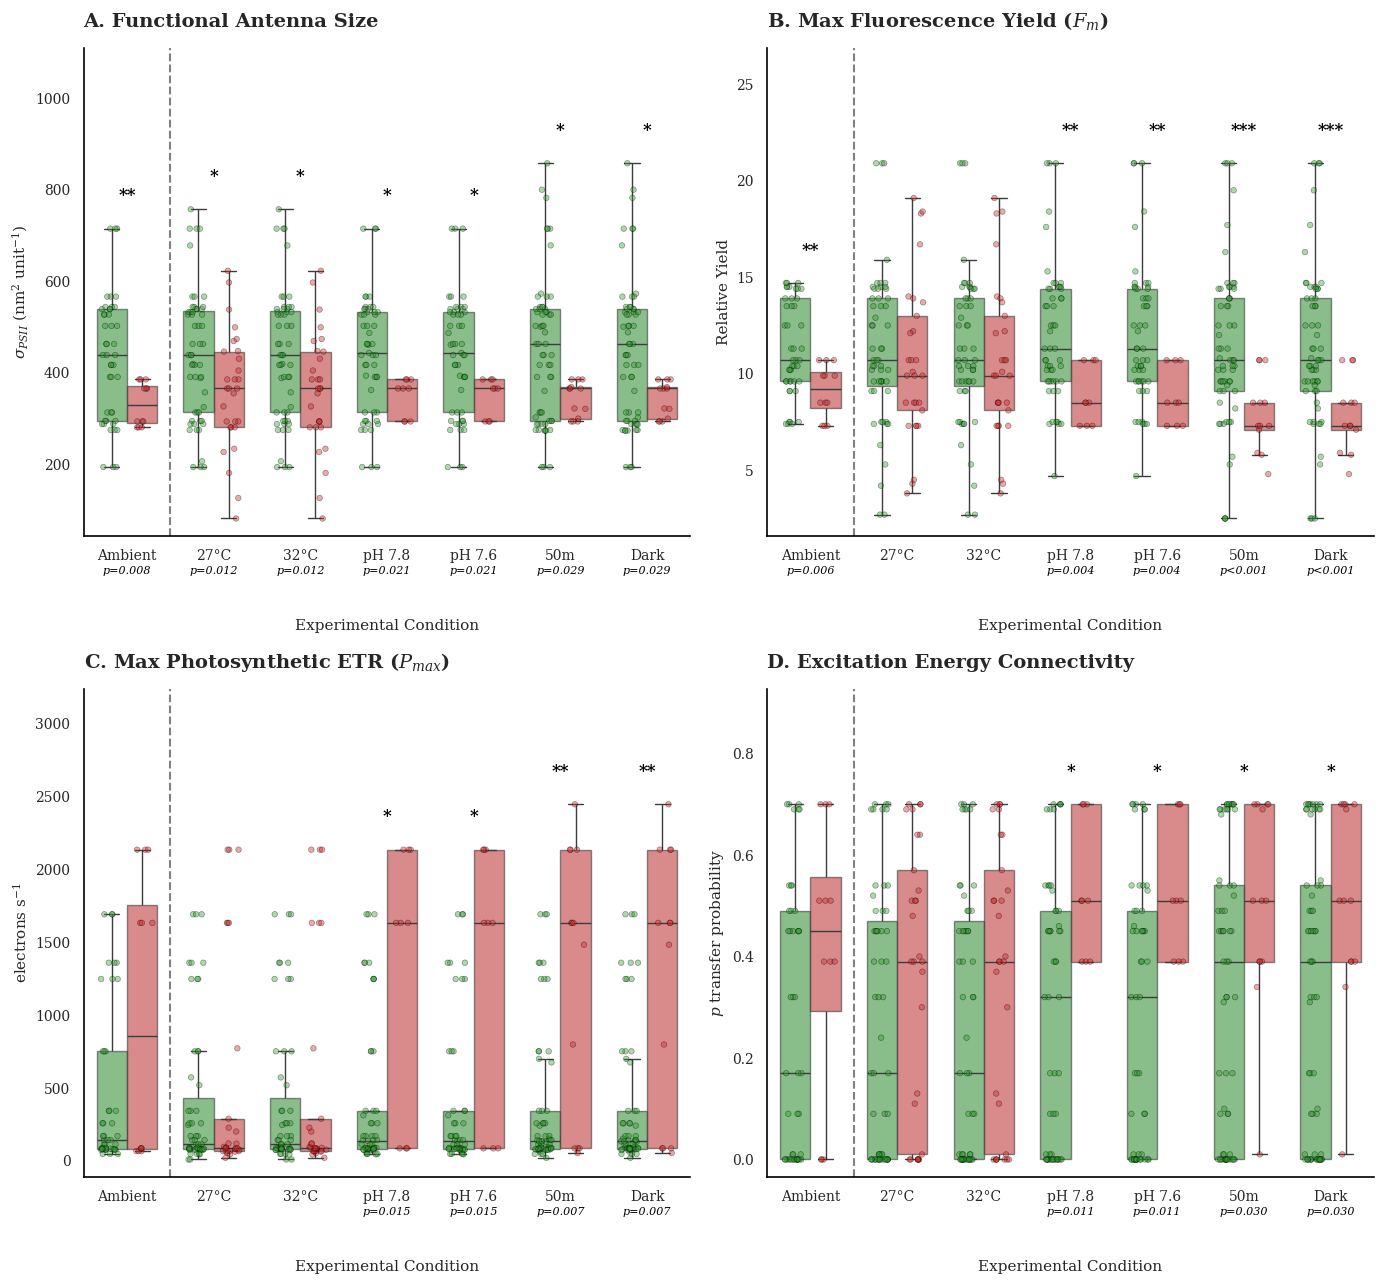

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

# 1. Setup Aesthetics for Professional Poster
sns.set_theme(style="white")
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
order = ['Ambient', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

fig, axes = plt.subplots(2, 2, figsize=(14, 13))
axes = axes.flatten()

plot_configs = [
    {'col': 'Sigma', 'label': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)', 'title': 'A. Functional Antenna Size'},
    {'col': 'Fm', 'label': 'Relative Yield', 'title': 'B. Max Fluorescence Yield ($F_m$)'},
    {'col': 'Pmax', 'label': 'electrons s$^{-1}$', 'title': 'C. Max Photosynthetic ETR ($P_{max}$)'},
    {'col': 'Connectivity', 'label': '$p$ transfer probability', 'title': 'D. Excitation Energy Connectivity'}
]

for i, config in enumerate(plot_configs):
    ax = axes[i]
    metric_col = config['col']
    if metric_col not in fire_clean.columns: continue

    # Draw Boxplots and Stripplots (legend=False to ensure no legend is drawn)
    sns.boxplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph', order=order,
                hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, width=0.7,
                boxprops=dict(alpha=0.6), showfliers=False, legend=False)

    sns.stripplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph', order=order,
                  hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, dodge=True,
                  size=4, alpha=0.4, jitter=0.2, edgecolor='black', linewidth=0.5, legend=False)

    # MAINTAIN Y-AXIS SPACE
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max + (y_max - y_min) * 0.25)

    # Re-calculate spacing
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    text_y_below = y_min - (y_range * 0.06)
    asterisk_y_pad = y_range * 0.05

    # --- SIGNIFICANCE-ONLY ANNOTATION ENGINE ---
    for idx, cond in enumerate(order):
        cond_data = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_data[cond_data['Morph'] == 'HF'][metric_col].dropna()
        nf = cond_data[cond_data['Morph'] == 'NF'][metric_col].dropna()

        if len(hf) >= 3 and len(nf) >= 3:
            # Normality Switch
            _, p_norm_hf = stats.shapiro(hf)
            _, p_norm_nf = stats.shapiro(nf)

            if p_norm_hf > 0.05 and p_norm_nf > 0.05:
                _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
            else:
                _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')

            if p_val < 0.05:
                sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
                local_max = max(hf.max(), nf.max())
                ax.text(idx, local_max + asterisk_y_pad, sig_text, ha='center',
                        va='bottom', color='black', fontsize=12, fontweight='bold', family='serif')

                p_label = f"p={p_val:.3f}" if p_val >= 0.001 else "p<0.001"
                ax.text(idx, text_y_below, p_label, ha='center', va='top',
                        color='black', fontsize=8, fontweight='normal',
                        fontstyle='italic', family='serif', clip_on=False)

    ax.set_title(config['title'], fontsize=14, fontweight='bold', loc='left', pad=15, family='serif')
    ax.set_xlabel("Experimental Condition", fontsize=11, labelpad=40, family='serif')
    ax.set_ylabel(config['label'], fontsize=11, family='serif')
    ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)

    # Explicitly remove any remaining legend objects
    if ax.get_legend():
        ax.get_legend().remove()

sns.despine()
plt.tight_layout()
plt.savefig("Combined_Spat_FIRe.png", dpi=600, bbox_inches='tight')
plt.savefig("Combined_Spat_FIRe.pdf", dpi=600, bbox_inches='tight')
plt.savefig("Combined_Spat_FIRe.svg", dpi=600, bbox_inches='tight')

plt.show()

### Block 6: Reproducibility & Version Tracking
This block documents the specific software and library versions used to generate this analysis and the final figure.

In [50]:
import pandas as pd
import numpy as np
import scipy
import statsmodels
import matplotlib
import seaborn as sns
import sys

print("=== REPRODUCIBILITY REPORT ===")
print(f"Python version:      {sys.version.split()[0]}")
print(f"Pandas version:      {pd.__version__}")
print(f"NumPy version:       {np.__version__}")
print(f"SciPy version:       {scipy.__version__}")
print(f"Statsmodels version: {statsmodels.__version__}")
print(f"Matplotlib version:  {matplotlib.__version__}")
print(f"Seaborn version:     {sns.__version__}")
print("==============================")

=== REPRODUCIBILITY REPORT ===
Python version:      3.12.13
Pandas version:      2.2.2
NumPy version:       2.0.2
SciPy version:       1.16.3
Statsmodels version: 0.14.6
Matplotlib version:  3.10.0
Seaborn version:     0.13.2
